In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')

sys.path.append('src')

from config.paths import config
from config.constants import TARGET_COLUMN, NON_MEDICAL_FEATURES, MISSING_VALUES
from src.data_loader import data_loader

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

In [4]:
print("Loading data...")
def _create_sample_data():
    np.random.seed(42)
    n_samples = 1000

    sample_data = {
        'DEMENTED': np.random.choice([0, 1], n_samples, p=[0.7, 0.3]),
        'SEX': np.random.choice([1, 2], n_samples),
        'RACE': np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.6, 0.2, 0.1, 0.05, 0.05]),
        'EDUC': np.random.randint(8, 20, n_samples),
        'MARISTAT': np.random.choice([1, 2, 3, 4, 5], n_samples, p=[0.5, 0.2, 0.1, 0.1, 0.1]),
        'NACCLIVS': np.random.choice([1, 2, 3, 4, 5], n_samples),
        'RESIDENC': np.random.choice([1, 2, 3, 4], n_samples, p=[0.6, 0.2, 0.1, 0.1]),
        'VISITYR': np.random.randint(2015, 2023, n_samples),
        'BIRTHYR': np.random.randint(1930, 1960, n_samples),
        'NACCAGE': np.random.randint(65, 95, n_samples),
        'HANDED': np.random.choice([1, 2, 3], n_samples, p=[0.1, 0.88, 0.02]),
        'HISPANIC': np.random.choice([0, 1], n_samples, p=[0.8, 0.2]),
        'PRIMLANG': np.random.choice([1, 2, 8], n_samples, p=[0.7, 0.2, 0.1]),
        'INDEPEND': np.random.choice([1, 2, 3, 4], n_samples, p=[0.5, 0.3, 0.15, 0.05]),
    }

    for col in ['EDUC', 'MARISTAT', 'HISPANIC']:
        mask = np.random.random(n_samples) < 0.05
        sample_data[col] = np.where(mask, np.nan, sample_data[col])

    df_sample = pd.DataFrame(sample_data)
    print("Created sample dataset with realistic distributions")
    return df_sample
try:
    df = data_loader.load_non_medical_data()

except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Creating sample dataset for EDA demonstration...")
    df = _create_sample_data()

except Exception as e:
    print(f"Unexpected error: {e}")
    print("Creating sample dataset for EDA demonstration...")
    df = _create_sample_data()

print(f"Final dataset shape: {df.shape}")
print(f"Target variable: {TARGET_COLUMN}")
print(f"Columns: {list(df.columns)}")


Loading data...
 Found data file at: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\data\raw\Dementia Prediction Dataset.csv
 File has 1024 total columns
 Loading 57 specified columns
 Successfully loaded data: 195196 rows, 57 columns
Final dataset shape: (195196, 57)
Target variable: DEMENTED
Columns: ['NACCID', 'NACCADC', 'PACKET', 'FORMVER', 'VISITMO', 'VISITDAY', 'VISITYR', 'NACCVNUM', 'NACCAVST', 'NACCNVST', 'NACCDAYS', 'NACCFDYS', 'BIRTHMO', 'BIRTHYR', 'SEX', 'HISPANIC', 'HISPOR', 'RACE', 'RACESEC', 'RACETER', 'PRIMLANG', 'EDUC', 'MARISTAT', 'NACCLIVS', 'INDEPEND', 'RESIDENC', 'HANDED', 'INBIRMO', 'INBIRYR', 'INSEX', 'INHISP', 'INHISPOR', 'NACCNINR', 'INRACE', 'INRASEC', 'INRATER', 'INEDUC', 'INRELTO', 'INLIVWTH', 'INVISITS', 'INCALLS', 'INRELY', 'NACCFAM', 'NACCMOM', 'NACCDAD', 'NACCFADM', 'NACCFFTD', 'TOBAC30', 'SMOKYRS', 'ALCFREQ', 'BILLS', 'SHOPPING', 'MEALPREP', 'DEMENTED', 'NACCAGEB', 'NACCNIHR', 'NACCAGE']


COMPREHENSIVE EXPLORATORY DATA ANALYSIS
1. DATA QUALITY AUDIT
----------------------------------------
Dataset Shape: (195196, 57)
Memory Usage: 102.20 MB
Missing Values Analysis
----------------------------------------
Top 20 features with missing values:
          missing_count  missing_percent
ALCFREQ          175941        90.135556
BILLS              8618         4.415049
BIRTHMO           16676         8.543208
EDUC               2092         1.071743
HANDED             1032         0.528699
HISPANIC            677         0.346831
HISPOR           181905        93.190947
INBIRMO           30601        15.677063
INBIRYR           13835         7.087748
INCALLS            8288         4.245989
INDEPEND            597         0.305846
INEDUC           138253        70.827783
INHISP           134934        69.127441
INHISPOR         189822        97.246870
INLIVWTH           8288         4.245989
INRACE           135264        69.296502
INRASEC          193480        99.120884
INRAT

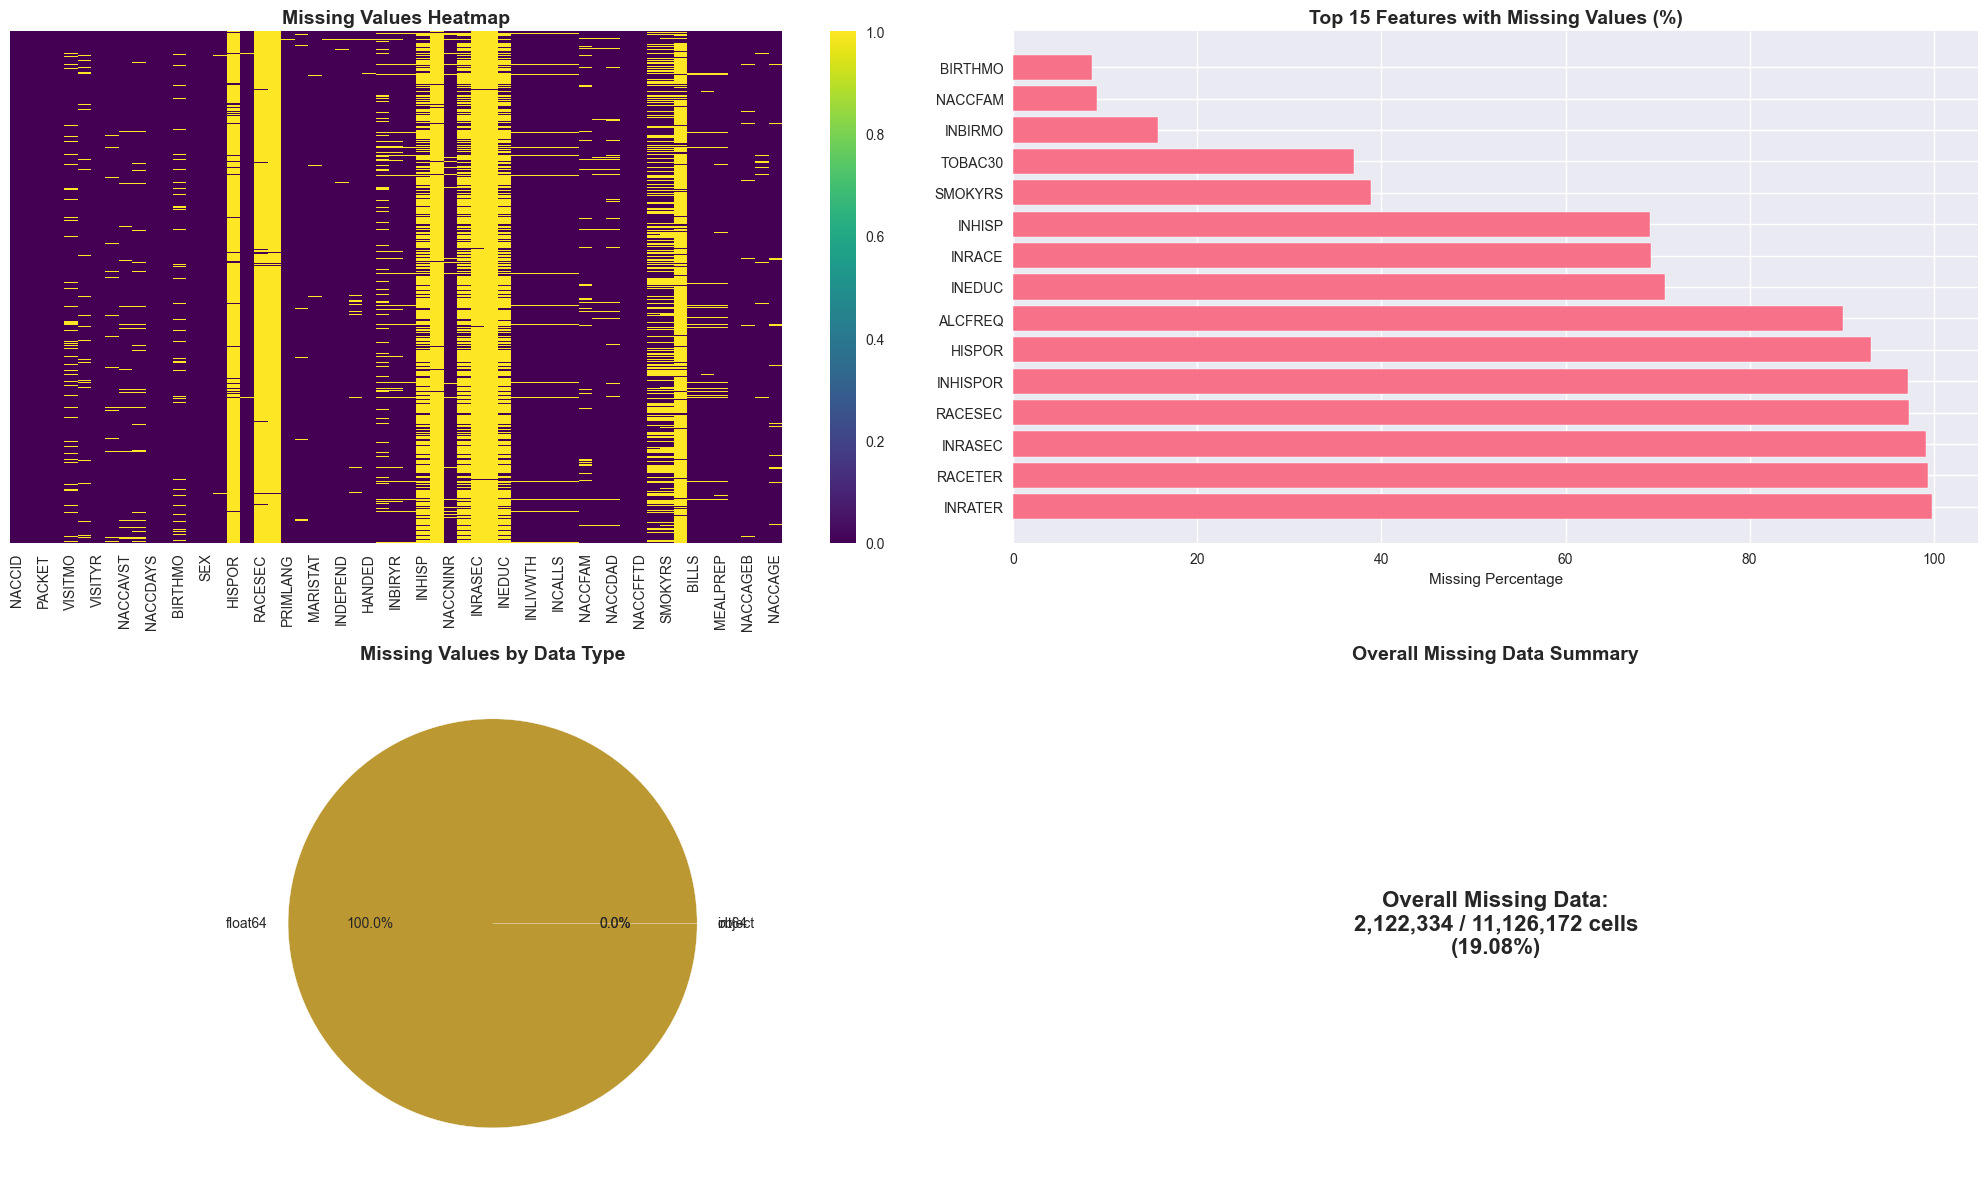

Duplicate Records Analysis
----------------------------------------
Total duplicate rows: 0
Duplicate percentage: 0.00%
Data Type Summary
----------------------------------------
Data types distribution:
float64    48
int64       7
object      2
Name: count, dtype: int64
Outlier Detection (IQR Method)
----------------------------------------
Top 15 features with highest outlier percentage:
     feature  outlier_percent  outlier_count      Q1      Q3     IQR
36  SHOPPING            15.96          31144     0.0     1.0     1.0
27   INRELTO            14.76          28810     1.0     2.0     1.0
17  MARISTAT             7.71          15050     1.0     2.0     1.0
18  NACCLIVS             7.51          14657     1.0     2.0     1.0
37  MEALPREP             6.94          13538     0.0     2.0     2.0
35     BILLS             6.67          13024     0.0     3.0     3.0
19  INDEPEND             5.51          10756     1.0     2.0     1.0
5   NACCVNUM             3.19           6220     1.0   

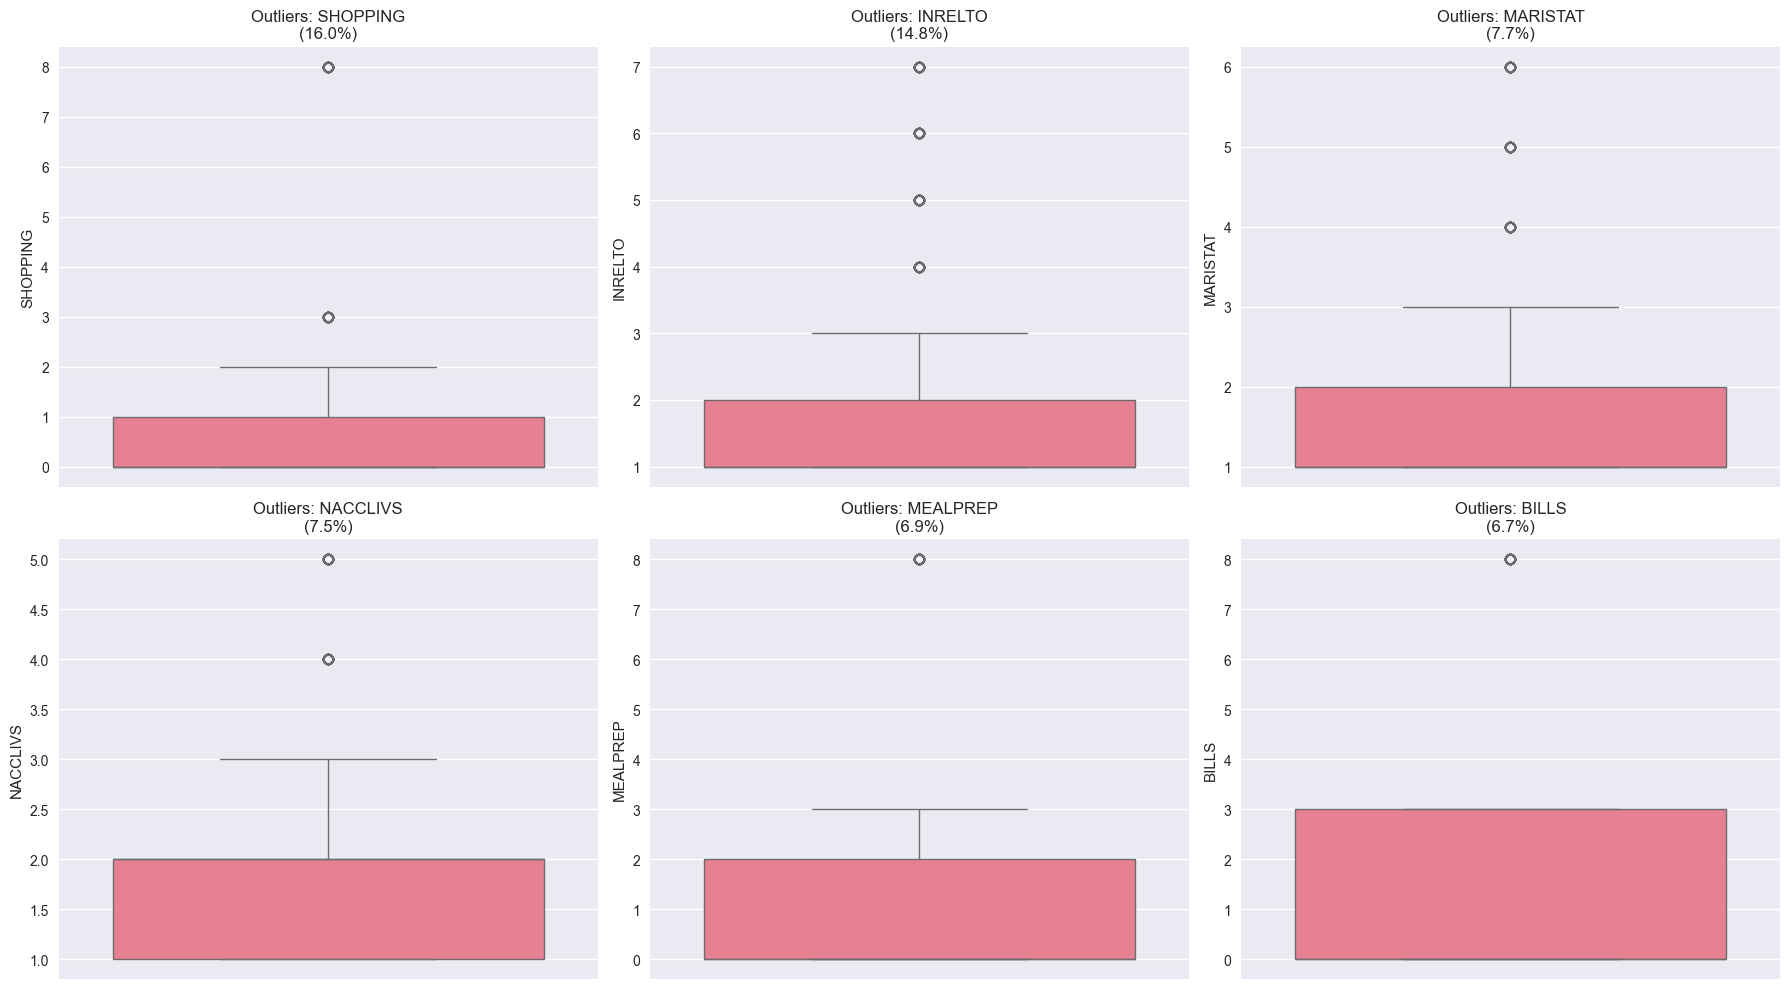

In [5]:
print("="*80)
print("COMPREHENSIVE EXPLORATORY DATA ANALYSIS")
print("="*80)

print("1. DATA QUALITY AUDIT")
print("-" * 40)

print(f"Dataset Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("Missing Values Analysis")
print("-" * 40)

missing_percent = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
missing_data = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_percent': missing_percent
})

print("Top 20 features with missing values:")
print(missing_data[missing_data['missing_count'] > 0].head(20))

fig, axes = plt.subplots(2, 2, figsize=(20, 12))

sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=axes[0,0])
axes[0,0].set_title('Missing Values Heatmap', fontsize=14, fontweight='bold')

missing_gt_zero = missing_percent[missing_percent > 0].head(15)
if len(missing_gt_zero) > 0:
    axes[0,1].barh(missing_gt_zero.index, missing_gt_zero.values)
    axes[0,1].set_title('Top 15 Features with Missing Values (%)', fontsize=14, fontweight='bold')
    axes[0,1].set_xlabel('Missing Percentage')
else:
    axes[0,1].text(0.5, 0.5, 'No Missing Values Found', ha='center', va='center', fontsize=16)
    axes[0,1].set_title('Missing Values Analysis', fontsize=14, fontweight='bold')

missing_by_dtype = df.isnull().sum().groupby(df.dtypes).sum()
if missing_by_dtype.sum() > 0:
    axes[1,0].pie(missing_by_dtype.values, labels=missing_by_dtype.index, autopct='%1.1f%%')
else:
    axes[1,0].pie([1], labels=['No Missing'], autopct='%1.1f%%')
axes[1,0].set_title('Missing Values by Data Type', fontsize=14, fontweight='bold')

total_missing = df.isnull().sum().sum()
total_cells = df.shape[0] * df.shape[1]
missing_overall_pct = (total_missing / total_cells) * 100
axes[1,1].text(0.5, 0.5, f'Overall Missing Data:\n{total_missing:,} / {total_cells:,} cells\n({missing_overall_pct:.2f}%)',
               ha='center', va='center', fontsize=16, fontweight='bold')
axes[1,1].set_title('Overall Missing Data Summary', fontsize=14, fontweight='bold')
axes[1,1].axis('off')

plt.tight_layout()
plt.show()

print(f"Duplicate Records Analysis")
print("-" * 40)
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate percentage: {(df.duplicated().sum() / len(df)) * 100:.2f}%")

print(f"Data Type Summary")
print("-" * 40)
print("Data types distribution:")
print(df.dtypes.value_counts())

print(f"Outlier Detection (IQR Method)")
print("-" * 40)

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
outlier_summary = []

for col in numerical_cols:
    if col != TARGET_COLUMN and df[col].notna().sum() > 0:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        if IQR > 0:
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
            outlier_percent = (len(outliers) / len(df)) * 100
            outlier_summary.append({
                'feature': col,
                'outlier_percent': outlier_percent,
                'outlier_count': len(outliers),
                'Q1': Q1,
                'Q3': Q3,
                'IQR': IQR
            })

if outlier_summary:
    outlier_df = pd.DataFrame(outlier_summary).sort_values('outlier_percent', ascending=False)
    print("Top 15 features with highest outlier percentage:")
    print(outlier_df.head(15).round(2))

    top_outlier_features = outlier_df.head(6)['feature'].tolist()
    if top_outlier_features:
        fig, axes = plt.subplots(2, 3, figsize=(18, 10))
        axes = axes.ravel()

        for i, feature in enumerate(top_outlier_features[:6]):
            if i < len(axes):
                sns.boxplot(y=df[feature], ax=axes[i])
                axes[i].set_title(f'Outliers: {feature}\n({outlier_df[outlier_df["feature"]==feature]["outlier_percent"].values[0]:.1f}%)')

        for i in range(len(top_outlier_features), 6):
            axes[i].axis('off')

        plt.tight_layout()
        plt.show()
else:
    print("No outliers detected in numerical features.")

2. TARGET VARIABLE ANALYSIS
----------------------------------------
Target Variable Distribution
----------------------------------------
Target variable: DEMENTED
Class distribution:
  Class 0: 137,606 samples (70.50%)
  Class 1: 57,590 samples (29.50%)
Demographic Breakdown by Target Variable
--------------------------------------------------
Available demographic features for analysis: ['SEX', 'RACE', 'MARISTAT', 'NACCLIVS', 'RESIDENC', 'EDUC']
SEX distribution by target:
DEMENTED      0      1
SEX                   
1         65.25  34.75
2         74.28  25.72
RACE distribution by target:
DEMENTED      0      1
RACE                  
1.0       69.11  30.89
2.0       79.80  20.20
3.0       71.70  28.30
4.0       54.72  45.28
5.0       76.25  23.75
50.0      52.87  47.13
MARISTAT distribution by target:
DEMENTED      0      1
MARISTAT              
1.0       66.66  33.34
2.0       71.78  28.22
3.0       81.11  18.89
4.0       75.83  24.17
5.0       83.60  16.40
6.0       77.47  22.

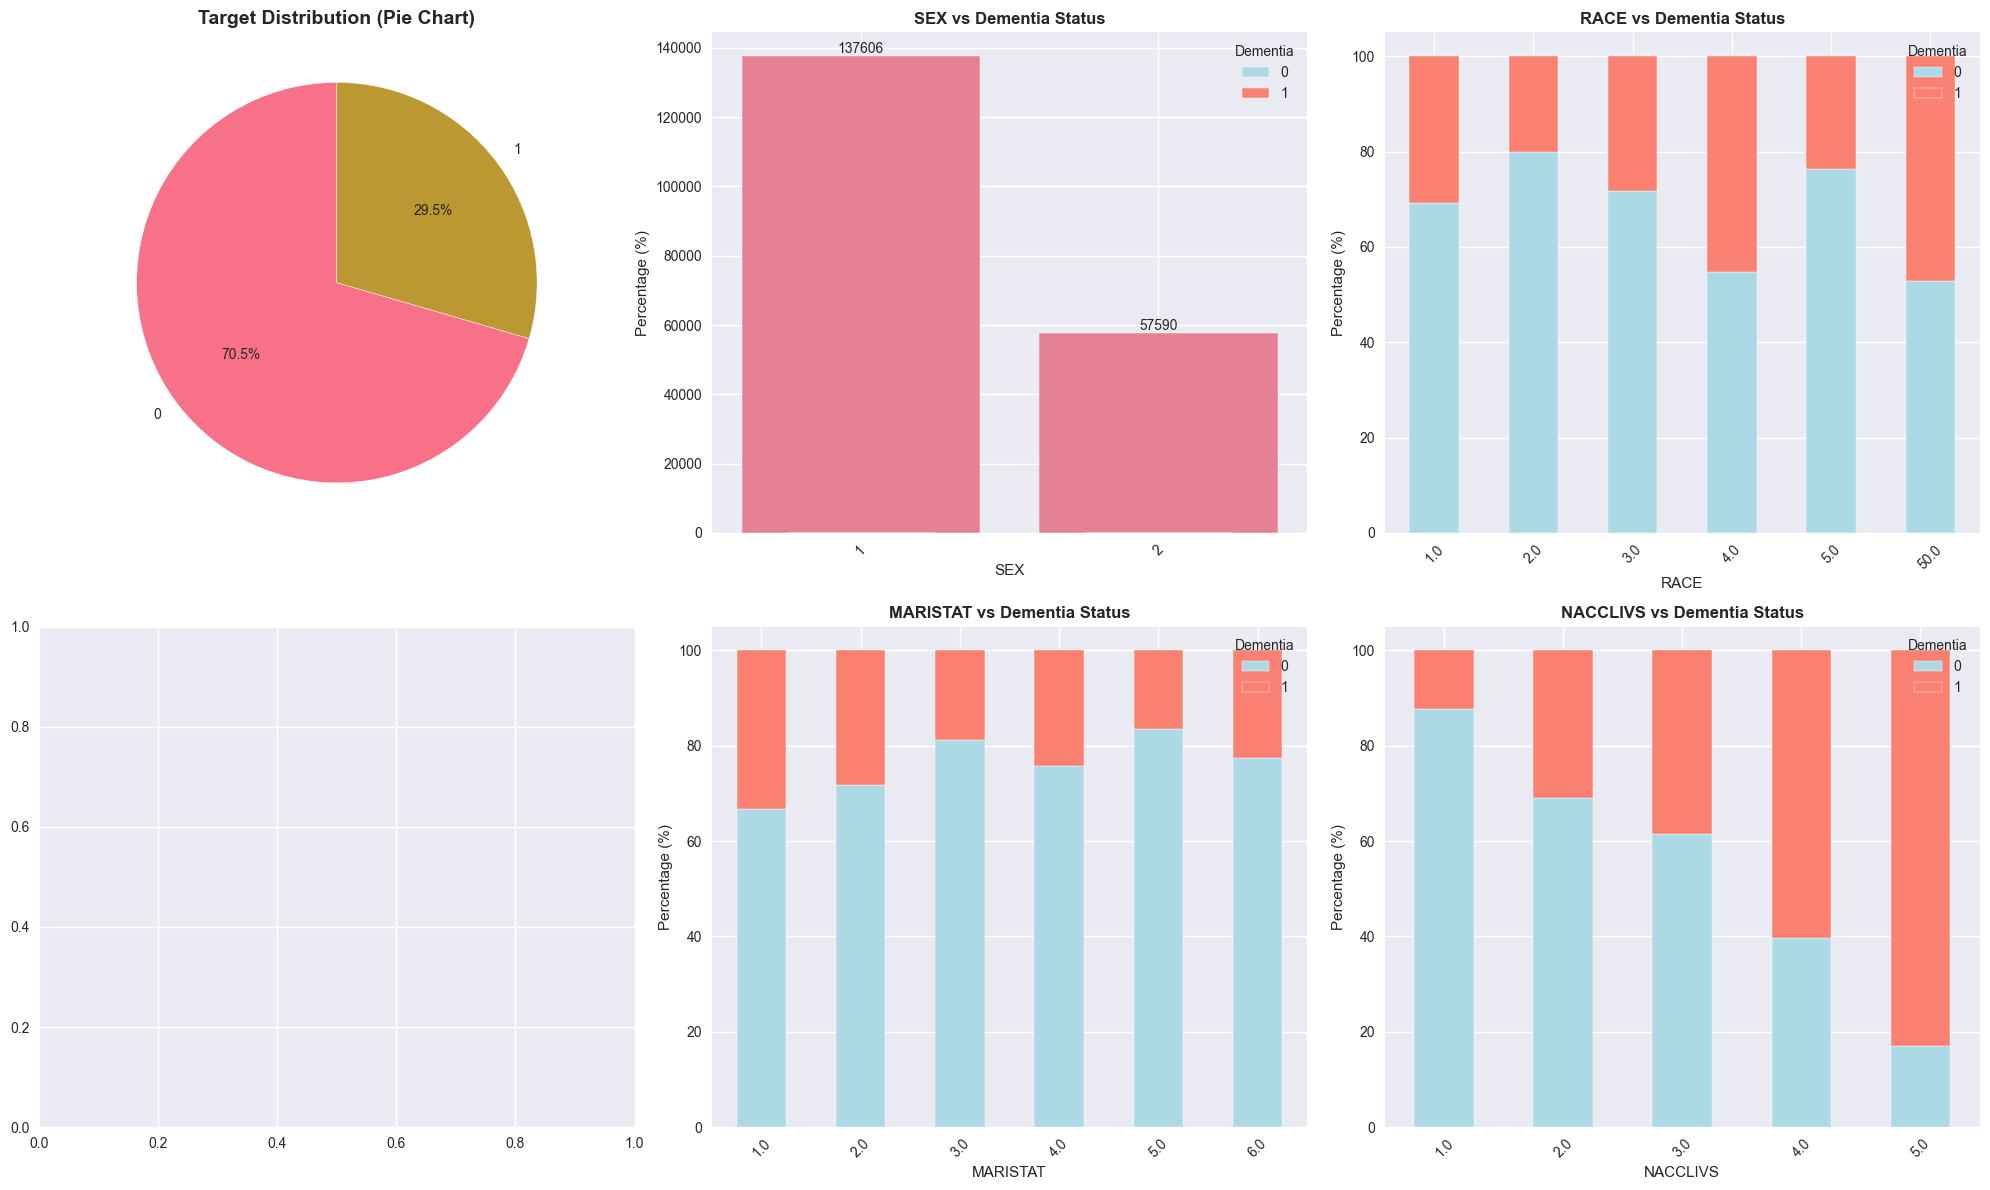

Time Trends Analysis
----------------------------------------


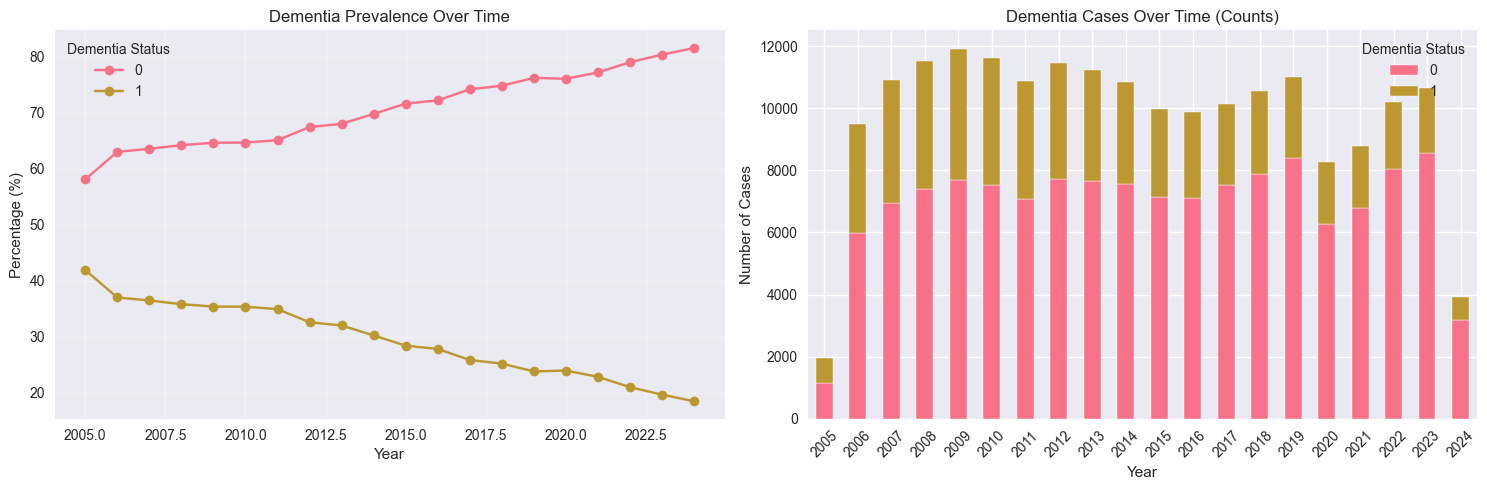

Yearly dementia prevalence:
DEMENTED      0      1
VISITYR               
2005      58.09  41.91
2006      62.99  37.01
2007      63.53  36.47
2008      64.19  35.81
2009      64.62  35.38
2010      64.65  35.35
2011      65.07  34.93
2012      67.42  32.58
2013      67.99  32.01
2014      69.77  30.23
2015      71.60  28.40
2016      72.19  27.81
2017      74.16  25.84
2018      74.80  25.20
2019      76.20  23.80
2020      76.04  23.96
2021      77.16  22.84
2022      79.01  20.99
2023      80.35  19.65
2024      81.52  18.48


In [6]:
print("2. TARGET VARIABLE ANALYSIS")
print("-" * 40)

print("Target Variable Distribution")
print("-" * 40)

target_counts = df[TARGET_COLUMN].value_counts()
target_percentages = df[TARGET_COLUMN].value_counts(normalize=True) * 100

print(f"Target variable: {TARGET_COLUMN}")
print(f"Class distribution:")
for class_val, count in target_counts.items():
    percentage = target_percentages[class_val]
    print(f"  Class {class_val}: {count:,} samples ({percentage:.2f}%)")

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

axes[0,0].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Target Distribution (Pie Chart)', fontsize=14, fontweight='bold')

sns.countplot(x=TARGET_COLUMN, data=df, ax=axes[0,1])
axes[0,1].set_title('Target Distribution (Bar Plot)', fontsize=14, fontweight='bold')
axes[0,1].set_xlabel('Dementia Status')
axes[0,1].set_ylabel('Count')

for container in axes[0,1].containers:
    axes[0,1].bar_label(container, fmt='%d', fontsize=10)

print(f"Demographic Breakdown by Target Variable")
print("-" * 50)

demographic_features = ['SEX', 'RACE', 'MARISTAT', 'NACCLIVS', 'RESIDENC', 'EDUC']
available_demographic = [f for f in demographic_features if f in df.columns]

print(f"Available demographic features for analysis: {available_demographic}")

for i, feature in enumerate(available_demographic[:4]):
    row = i // 2
    col = i % 2 + 1

    if feature in df.columns and df[feature].notna().sum() > 0:
        cross_tab = pd.crosstab(df[feature], df[TARGET_COLUMN], normalize='index') * 100

        cross_tab.plot(kind='bar', stacked=True, ax=axes[row, col],
                      color=['lightblue', 'salmon'])
        axes[row, col].set_title(f'{feature} vs Dementia Status', fontsize=12, fontweight='bold')
        axes[row, col].set_ylabel('Percentage (%)')
        axes[row, col].tick_params(axis='x', rotation=45)
        axes[row, col].legend(title='Dementia', loc='upper right')

        print(f"{feature} distribution by target:")
        print(cross_tab.round(2))

for i in range(len(available_demographic[:4]), 4):
    row = i // 2
    col = i % 2 + 1
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

print(f"Time Trends Analysis")
print("-" * 40)

if 'VISITYR' in df.columns:
    plt.figure(figsize=(15, 5))

    yearly_trend = df.groupby('VISITYR')[TARGET_COLUMN].value_counts(normalize=True).unstack() * 100

    plt.subplot(1, 2, 1)
    yearly_trend.plot(kind='line', marker='o', ax=plt.gca())
    plt.title('Dementia Prevalence Over Time')
    plt.xlabel('Year')
    plt.ylabel('Percentage (%)')
    plt.legend(title='Dementia Status')
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    yearly_counts = df.groupby('VISITYR')[TARGET_COLUMN].value_counts().unstack()
    yearly_counts.plot(kind='bar', stacked=True, ax=plt.gca())
    plt.title('Dementia Cases Over Time (Counts)')
    plt.xlabel('Year')
    plt.ylabel('Number of Cases')
    plt.legend(title='Dementia Status')
    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()

    print("Yearly dementia prevalence:")
    print(yearly_trend.round(2))

3. FEATURE CLASSIFICATION TABLE
Medical vs Non-Medical Feature Classification
------------------------------------------------------------
Feature Category Summary:
Category
Non-Medical    56
Target          1
Name: count, dtype: int64
Detailed Feature Classification (first 30 features):
     Feature     Category Data Type  Missing %  Unique Values  \
0     NACCID  Non-Medical    object       0.00          52537   
1    NACCADC  Non-Medical     int64       0.00             46   
2     PACKET  Non-Medical    object       0.00              4   
3    FORMVER  Non-Medical   float64       0.00              4   
4    VISITMO  Non-Medical   float64       8.17             11   
5   VISITDAY  Non-Medical   float64       3.58             30   
6    VISITYR  Non-Medical     int64       0.00             20   
7   NACCVNUM  Non-Medical   float64       2.63             19   
8   NACCAVST  Non-Medical   float64       5.45             19   
9   NACCNVST  Non-Medical   float64       4.99             19

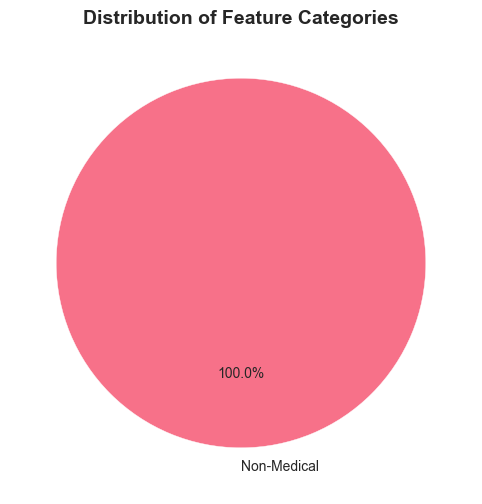

In [7]:
print("3. FEATURE CLASSIFICATION TABLE")
print("="*80)

print("Medical vs Non-Medical Feature Classification")
print("-" * 60)

feature_classification = []
for col in df.columns:
    if col == TARGET_COLUMN:
        category = "Target"
        justification = "Prediction target variable"
    elif col in NON_MEDICAL_FEATURES:
        category = "Non-Medical"
        if any(keyword in col.lower() for keyword in ['demo', 'birth', 'sex', 'race', 'educ', 'marital']):
            justification = "Demographic information"
        elif any(keyword in col.lower() for keyword in ['visit', 'packet', 'form']):
            justification = "Administrative/visit data"
        elif any(keyword in col.lower() for keyword in ['family', 'fam', 'mom', 'dad']):
            justification = "Family history (genetic/non-medical context)"
        elif any(keyword in col.lower() for keyword in ['lang', 'living', 'resid']):
            justification = "Lifestyle/socioeconomic factor"
                # In your EDA notebook - update the classification logic
        elif any(keyword in col.lower() for keyword in ['tobac', 'smok', 'alcfreq']):
            justification = "Lifestyle factor (substance use)"
        elif any(keyword in col.lower() for keyword in ['bills', 'shopping', 'mealprep']):
            justification = "Functional ability (ADLs)"
        else:
            justification = "Non-medical background information"
    else:
        category = "Medical"
        justification = "Clinical/medical measurement or diagnosis"

    feature_classification.append({
        'Feature': col,
        'Category': category,
        'Data Type': df[col].dtype,
        'Missing %': round((df[col].isnull().sum() / len(df)) * 100, 2),
        'Unique Values': df[col].nunique(),
        'Justification': justification
    })

classification_df = pd.DataFrame(feature_classification)

print("Feature Category Summary:")
category_summary = classification_df['Category'].value_counts()
print(category_summary)

print(f"Detailed Feature Classification (first 30 features):")
print(classification_df.head(30))

classification_file = config.reports_dir / "feature_classification.csv"
classification_df.to_csv(classification_file, index=False)
print(f"Full feature classification saved to: {classification_file}")

plt.figure(figsize=(10, 6))
category_counts = classification_df[classification_df['Category'] != 'Target']['Category'].value_counts()
plt.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Distribution of Feature Categories', fontsize=14, fontweight='bold')
plt.show()

4. FEATURE-TARGET RELATIONSHIP ANALYSIS
Correlation Analysis
----------------------------------------
Analyzing correlations for 35 numerical features
Top 10 features most correlated with target:
  INDEPEND: 0.735
  SHOPPING: 0.609
  BILLS: 0.514
  MEALPREP: 0.450
  NACCLIVS: 0.298
  RESIDENC: 0.238
  INCALLS: 0.142
  ALCFREQ: 0.117
  INVISITS: 0.062
Bottom 10 features least correlated with target:
  INEDUC: -0.045
  NACCVNUM: -0.098
  FORMVER: -0.112
  MARISTAT: -0.113
  VISITYR: -0.128
  EDUC: -0.134
  INRATER: -0.143
  INRELTO: -0.161
  NACCAVST: -0.255
  NACCNVST: -0.295


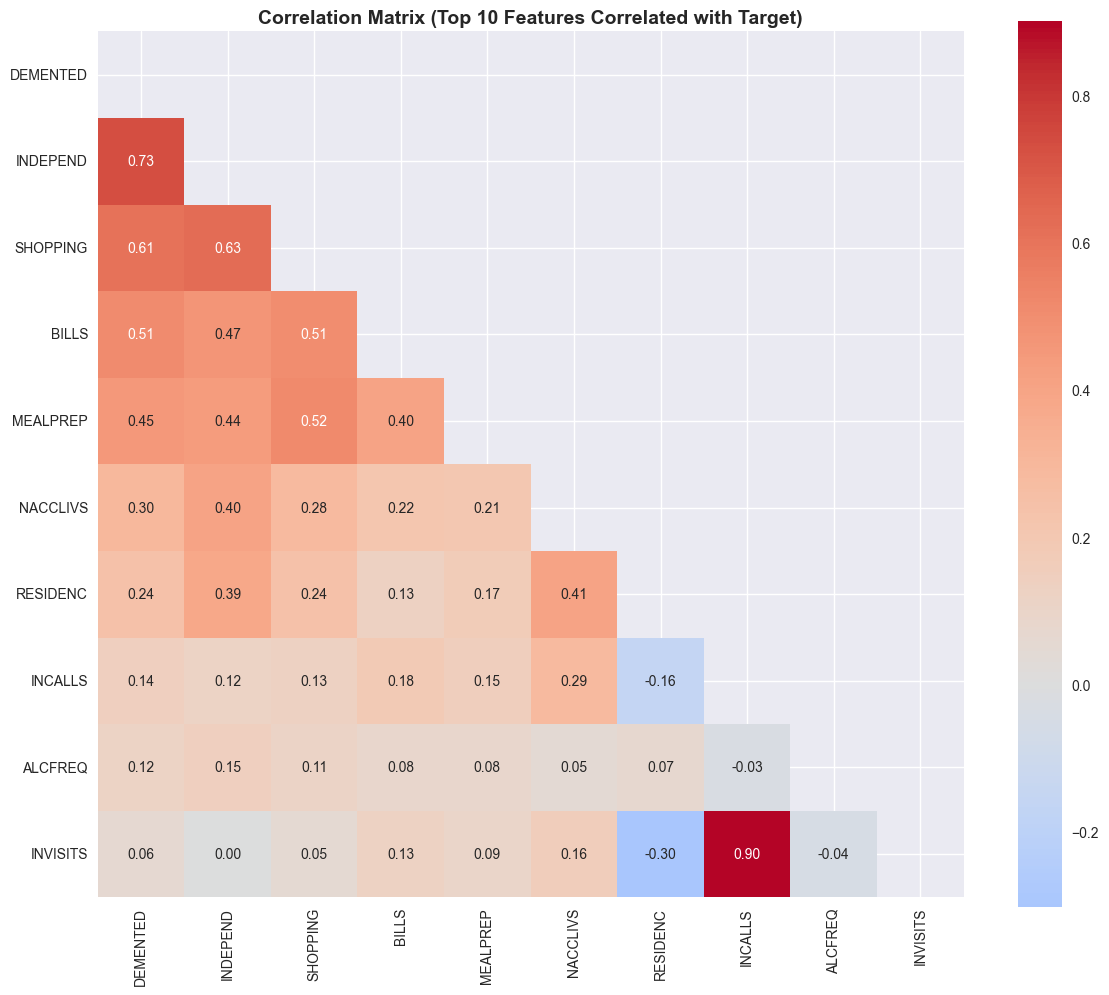

Statistical Significance Tests
---------------------------------------------
Performing chi-square tests on 2 categorical features...
  NACCID               : p-value = 0.000000 ***
  PACKET               : p-value = 0.000000 ***
Found 2 statistically significant categorical features (p < 0.05)
Performing t-tests on 55 numerical features...
  NACCADC              : p-value = 0.000000 ***
  FORMVER              : p-value = 0.000000 ***
  VISITMO              : p-value = 0.756793 
  VISITDAY             : p-value = 0.214297 
  VISITYR              : p-value = 0.000000 ***
  NACCVNUM             : p-value = 0.000000 ***
  NACCAVST             : p-value = 0.000000 ***
  NACCNVST             : p-value = 0.000000 ***
  NACCDAYS             : p-value = 0.000000 ***
  NACCFDYS             : p-value = 0.000000 ***
  BIRTHMO              : p-value = 0.797677 
  BIRTHYR              : p-value = 0.000000 ***
  SEX                  : p-value = 0.000000 ***
  HISPANIC             : p-value = 0.00000

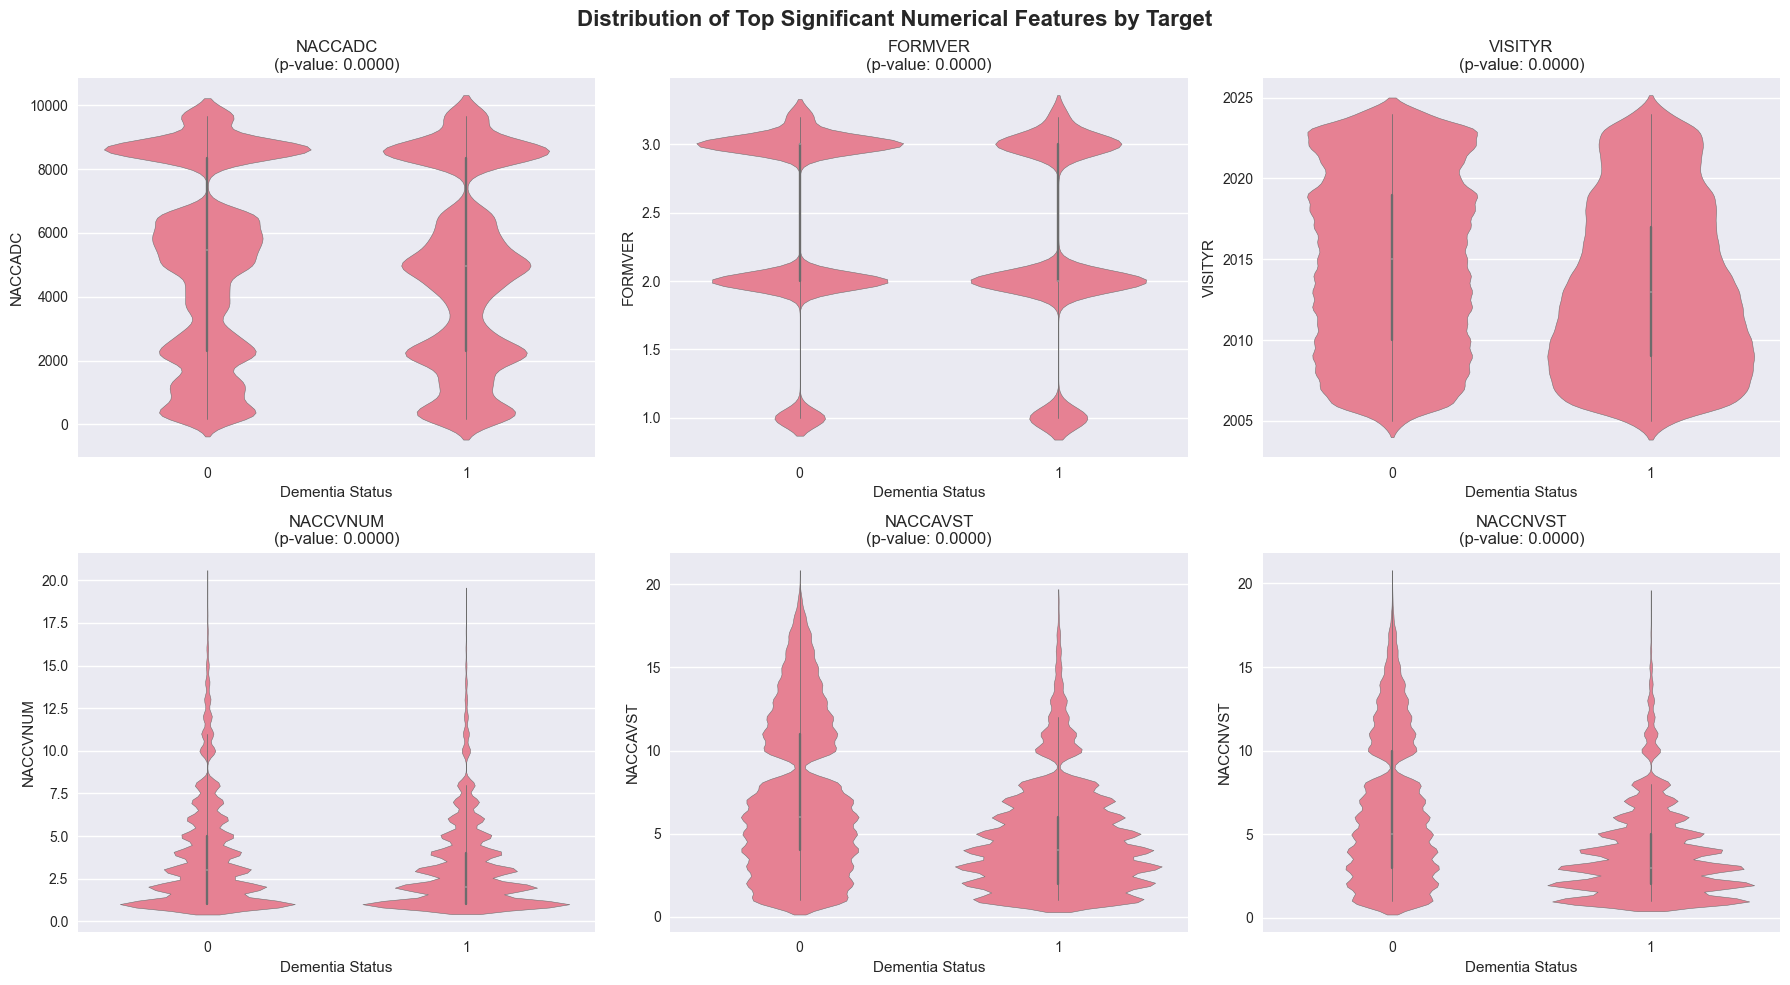

In [8]:
print("4. FEATURE-TARGET RELATIONSHIP ANALYSIS")
print("="*80)

print("Correlation Analysis")
print("-" * 40)

numerical_for_corr = [col for col in numerical_cols
                     if col != TARGET_COLUMN
                     and df[col].nunique() > 2
                     and df[col].nunique() <= 50
                     and df[col].notna().sum() > 100]

print(f"Analyzing correlations for {len(numerical_for_corr)} numerical features")

if len(numerical_for_corr) > 0:
    corr_with_target = df[numerical_for_corr + [TARGET_COLUMN]].corr()[TARGET_COLUMN].sort_values(ascending=False)

    print("Top 10 features most correlated with target:")
    for feature, corr in corr_with_target.head(10).items():
        if feature != TARGET_COLUMN:
            print(f"  {feature}: {corr:.3f}")

    print("Bottom 10 features least correlated with target:")
    for feature, corr in corr_with_target.tail(10).items():
        if feature != TARGET_COLUMN:
            print(f"  {feature}: {corr:.3f}")

    top_corr_features = corr_with_target.head(10).index.tolist()
    if len(top_corr_features) > 1:
        plt.figure(figsize=(12, 10))
        correlation_matrix = df[top_corr_features].corr()
        mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

        sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm',
                   center=0, fmt='.2f', square=True)
        plt.title('Correlation Matrix (Top 10 Features Correlated with Target)',
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

print(f"Statistical Significance Tests")
print("-" * 45)

categorical_features = df.select_dtypes(include=['object', 'category']).columns.tolist()
categorical_features = [f for f in categorical_features if f != TARGET_COLUMN and df[f].nunique() > 1]

print(f"Performing chi-square tests on {len(categorical_features)} categorical features...")

significant_features = []
for feature in categorical_features[:10]:
    try:
        contingency_table = pd.crosstab(df[feature], df[TARGET_COLUMN])

        if contingency_table.shape[0] >= 2 and contingency_table.shape[1] >= 2:
            chi2, p_value, dof, expected = chi2_contingency(contingency_table)

            if p_value < 0.001:
                sig_level = '***'
            elif p_value < 0.01:
                sig_level = '**'
            elif p_value < 0.05:
                sig_level = '*'
            else:
                sig_level = ''

            print(f"  {feature:20} : p-value = {p_value:.6f} {sig_level}")

            if p_value < 0.05:
                significant_features.append((feature, p_value))
    except Exception as e:
        print(f"  {feature:20} : Error in test - {str(e)[:50]}")

print(f"Found {len(significant_features)} statistically significant categorical features (p < 0.05)")

print(f"Performing t-tests on {len(numerical_cols)} numerical features...")

significant_numerical = []
for feature in numerical_cols[:15]:
    if feature != TARGET_COLUMN and df[feature].notna().sum() > 10:
        try:
            group0 = df[df[TARGET_COLUMN] == 0][feature].dropna()
            group1 = df[df[TARGET_COLUMN] == 1][feature].dropna()

            if len(group0) > 1 and len(group1) > 1:
                t_stat, p_value = ttest_ind(group0, group1, equal_var=False)

                if p_value < 0.001:
                    sig_level = '***'
                elif p_value < 0.01:
                    sig_level = '**'
                elif p_value < 0.05:
                    sig_level = '*'
                else:
                    sig_level = ''

                print(f"  {feature:20} : p-value = {p_value:.6f} {sig_level}")

                if p_value < 0.05:
                    significant_numerical.append((feature, p_value))
        except Exception as e:
            print(f"  {feature:20} : Error in test - {str(e)[:50]}")

print(f"Found {len(significant_numerical)} statistically significant numerical features (p < 0.05)")

if significant_numerical:
    top_sig_features = [f[0] for f in significant_numerical[:6]]

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.ravel()

    for i, feature in enumerate(top_sig_features[:6]):
        if i < len(axes):
            sns.violinplot(x=TARGET_COLUMN, y=feature, data=df, ax=axes[i])
            axes[i].set_title(f'{feature}\n(p-value: {significant_numerical[i][1]:.4f})')
            axes[i].set_xlabel('Dementia Status')

    for i in range(len(top_sig_features), 6):
        axes[i].axis('off')

    plt.suptitle('Distribution of Top Significant Numerical Features by Target',
                fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

5. ADVANCED EDA
Feature Interaction Analysis
----------------------------------------
Interaction: EDUC vs NACCLIVS


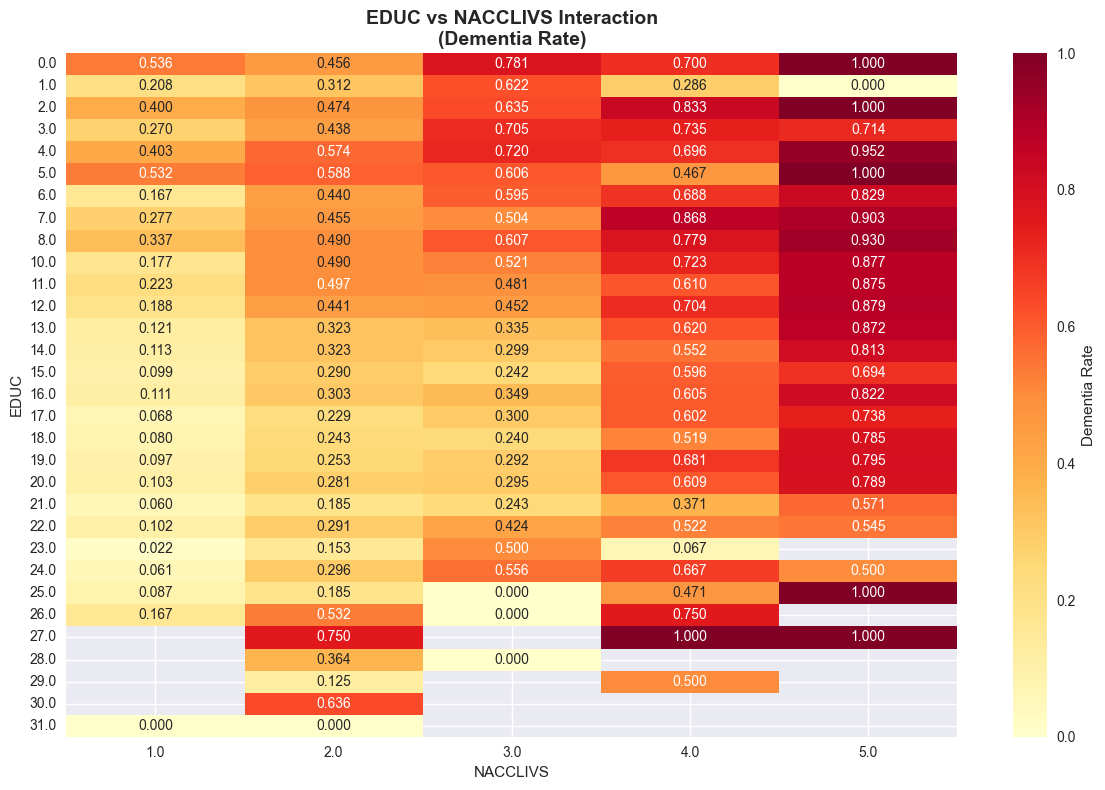

Interaction: SEX vs MARISTAT


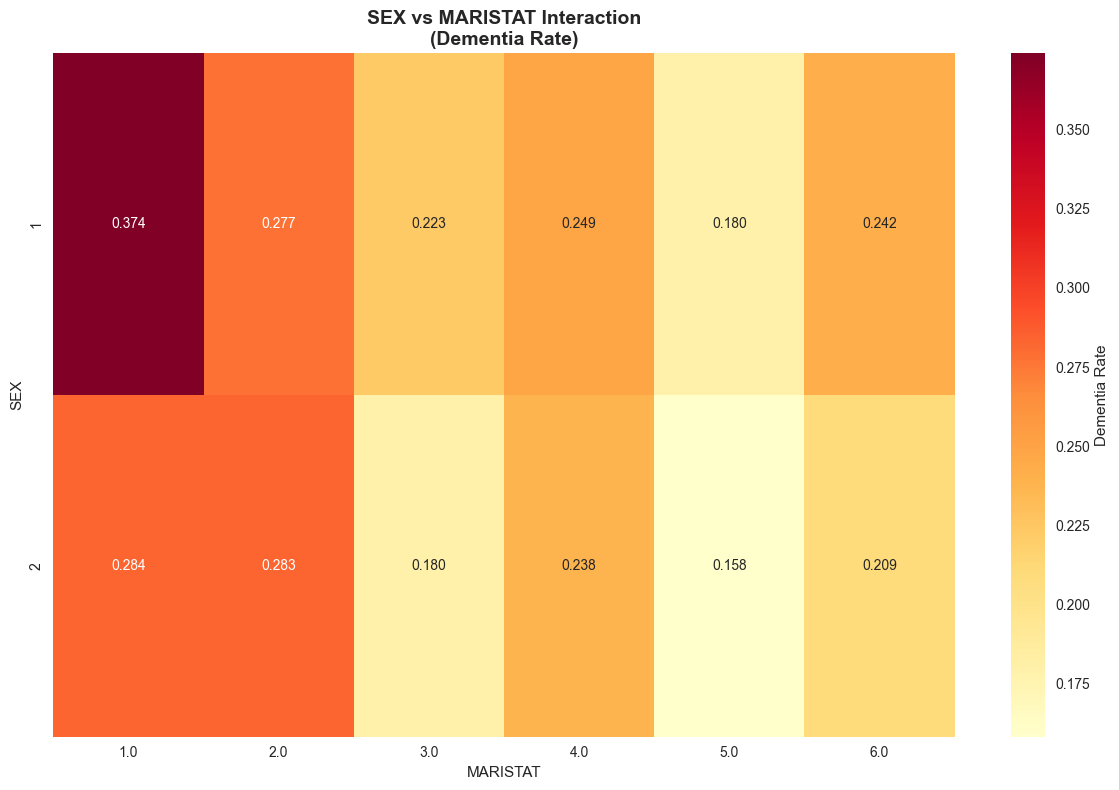

Interaction: RACE vs RESIDENC


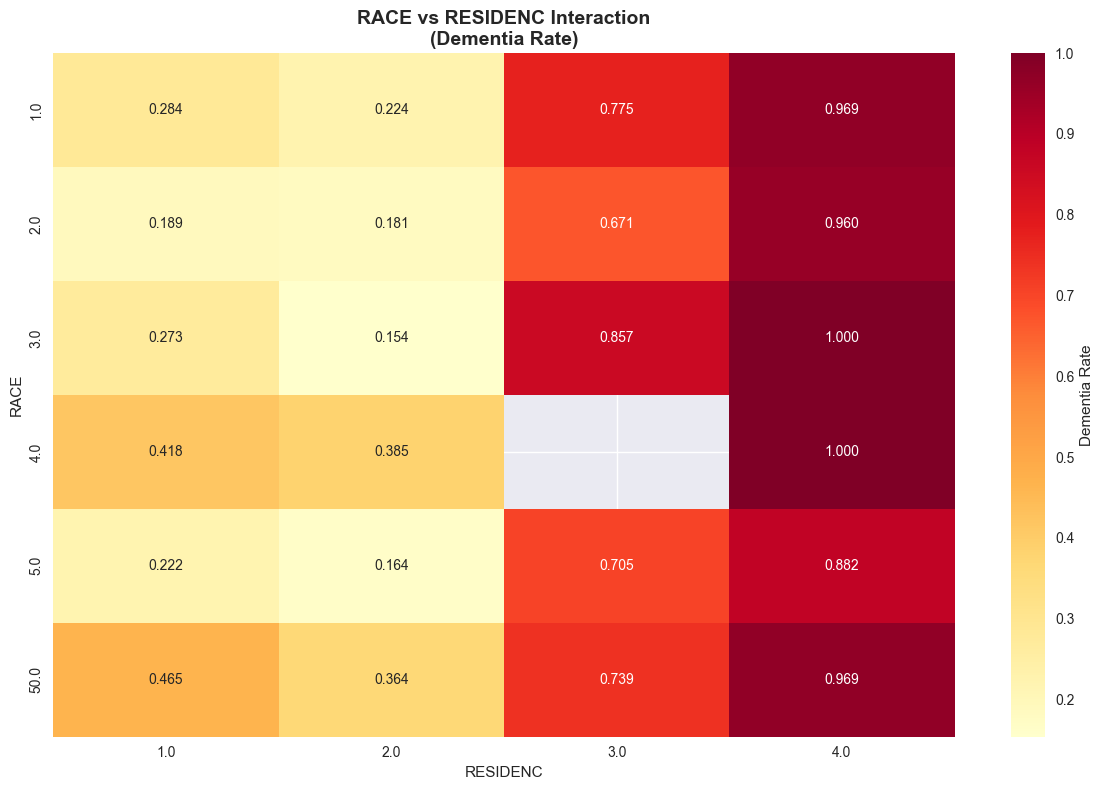

Multicollinearity Analysis
----------------------------------------
DATA QUALITY RECOMMENDATIONS
--------------------------------------------------
CRITICAL ISSUES (Address First):
  • DROP: 'HISPOR' - 93.2% missing data
  • DROP: 'RACESEC' - 97.3% missing data
  • DROP: 'RACETER' - 99.4% missing data
  • INVESTIGATE: 'INHISP' - 69.1% missing data
  • DROP: 'INHISPOR' - 97.2% missing data
  • INVESTIGATE: 'INRACE' - 69.3% missing data
  • DROP: 'INRASEC' - 99.1% missing data
  • DROP: 'INRATER' - 99.8% missing data
  • INVESTIGATE: 'INEDUC' - 70.8% missing data
  • DROP: 'ALCFREQ' - 90.1% missing data
MODERATE ISSUES (Address Next):
  • PROCESS: 'NACCID' - high cardinality (52537 values)
  • IMPUTE: 'TOBAC30' - 37.0% missing
  • IMPUTE: 'SMOKYRS' - 38.9% missing
MINOR ISSUES (Address Last):
  • IMPUTE: 'VISITMO' - 8.2% missing
  • IMPUTE: 'VISITDAY' - 3.6% missing
  • IMPUTE: 'NACCVNUM' - 2.6% missing
  • IMPUTE: 'NACCAVST' - 5.5% missing
  • IMPUTE: 'NACCNVST' - 5.0% missing
  • IMPUT

In [9]:
print("5. ADVANCED EDA")
print("="*80)

print("Feature Interaction Analysis")
print("-" * 40)

interaction_pairs = [
    ('EDUC', 'NACCLIVS'),
    ('SEX', 'MARISTAT'),
    ('RACE', 'RESIDENC'),
]

for feature1, feature2 in interaction_pairs:
    if feature1 in df.columns and feature2 in df.columns:
        print(f"Interaction: {feature1} vs {feature2}")

        interaction_data = df.groupby([feature1, feature2])[TARGET_COLUMN].mean().unstack()

        plt.figure(figsize=(12, 8))
        sns.heatmap(interaction_data, annot=True, cmap='YlOrRd', fmt='.3f',
                   cbar_kws={'label': 'Dementia Rate'})
        plt.title(f'{feature1} vs {feature2} Interaction\n(Dementia Rate)',
                 fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()

print(f"Multicollinearity Analysis")
print("-" * 40)

non_medical_numerical = [col for col in NON_MEDICAL_FEATURES
                        if col in df.columns
                        and df[col].dtype in [np.number]
                        and df[col].nunique() > 2]

if len(non_medical_numerical) > 1:
    nm_correlation = df[non_medical_numerical].corr()

    high_corr_pairs = []
    for i in range(len(nm_correlation.columns)):
        for j in range(i+1, len(nm_correlation.columns)):
            if abs(nm_correlation.iloc[i, j]) > 0.7:
                high_corr_pairs.append((
                    nm_correlation.columns[i],
                    nm_correlation.columns[j],
                    nm_correlation.iloc[i, j]
                ))

    print(f"Found {len(high_corr_pairs)} highly correlated feature pairs (|r| > 0.7):")
    for pair in high_corr_pairs[:10]:
        print(f"  {pair[0]} - {pair[1]}: {pair[2]:.3f}")

    plt.figure(figsize=(12, 10))
    mask = np.triu(np.ones_like(nm_correlation, dtype=bool))
    sns.heatmap(nm_correlation, mask=mask, annot=True, cmap='coolwarm',
               center=0, fmt='.2f', square=True)
    plt.title('Multicollinearity Check: Non-Medical Features Correlation',
             fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

print(f"DATA QUALITY RECOMMENDATIONS")
print("-" * 50)

recommendations = []
critical_issues = []
moderate_issues = []
minor_issues = []

for col in df.columns:
    missing_pct = (df[col].isnull().sum() / len(df)) * 100
    unique_vals = df[col].nunique()
    data_type = df[col].dtype

    if missing_pct > 80:
        critical_issues.append(f"DROP: '{col}' - {missing_pct:.1f}% missing data")
        recommendations.append(f"CRITICAL: Drop '{col}' ({missing_pct:.1f}% missing)")

    elif missing_pct > 50:
        critical_issues.append(f"INVESTIGATE: '{col}' - {missing_pct:.1f}% missing data")
        recommendations.append(f"CRITICAL: Investigate dropping '{col}' ({missing_pct:.1f}% missing)")

    elif missing_pct > 20:
        moderate_issues.append(f"IMPUTE: '{col}' - {missing_pct:.1f}% missing")
        recommendations.append(f"MODERATE: Advanced imputation needed for '{col}' ({missing_pct:.1f}% missing)")

    elif unique_vals == 1:
        critical_issues.append(f"DROP: '{col}' - constant value")
        recommendations.append(f"CRITICAL: Drop '{col}' (constant value)")

    elif unique_vals == 2 and data_type == 'object':
        moderate_issues.append(f"ENCODE: '{col}' - binary categorical")
        recommendations.append(f"MODERATE: Binary encode '{col}' ({unique_vals} unique values)")

    elif unique_vals > 50 and data_type == 'object':
        moderate_issues.append(f"PROCESS: '{col}' - high cardinality ({unique_vals} values)")
        recommendations.append(f"MODERATE: Handle high cardinality in '{col}' ({unique_vals} unique values)")

    elif missing_pct > 0:
        minor_issues.append(f"IMPUTE: '{col}' - {missing_pct:.1f}% missing")
        recommendations.append(f"MINOR: Simple imputation for '{col}' ({missing_pct:.1f}% missing)")

    else:
        recommendations.append(f"GOOD: '{col}' - No major issues")

print("CRITICAL ISSUES (Address First):")
for issue in critical_issues[:10]:
    print(f"  • {issue}")

print("MODERATE ISSUES (Address Next):")
for issue in moderate_issues[:10]:
    print(f"  • {issue}")

print("MINOR ISSUES (Address Last):")
for issue in minor_issues[:10]:
    print(f"  • {issue}")

print(f"Summary:")
print(f"  Critical issues: {len(critical_issues)}")
print(f"  Moderate issues: {len(moderate_issues)}")
print(f"  Minor issues: {len(minor_issues)}")
print(f"  Total features: {len(df.columns)}")

In [10]:
print("="*80)
print("EDA COMPREHENSIVE SUMMARY")
print("="*80)

summary_stats = {
    'Dataset Dimensions': f"{df.shape[0]:,} rows × {df.shape[1]:,} columns",
    'Total Features': len(df.columns),
    'Non-Medical Features': len([col for col in NON_MEDICAL_FEATURES if col in df.columns]),
    'Target Variable': TARGET_COLUMN,
    'Target Distribution': f"{target_counts.get(0, 0):,} (No Dementia) vs {target_counts.get(1, 0):,} (Dementia)",
    'Overall Missing Data': f"{(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%",
    'Duplicate Rows': f"{df.duplicated().sum():,} ({(df.duplicated().sum() / len(df) * 100):.2f}%)",
    'Significant Features Found': f"{len(significant_features) + len(significant_numerical)} (p < 0.05)"
}

print("KEY FINDINGS:")
for key, value in summary_stats.items():
    print(f"  {key}: {value}")

print(f"RECOMMENDATIONS FOR NEXT STEPS:")
print("  1. Address critical data quality issues first")
print("  2. Implement appropriate imputation strategies")
print("  3. Encode categorical variables based on cardinality")
print("  4. Consider feature selection based on statistical significance")
print("  5. Handle outliers in key numerical features")
print("  6. Validate target variable definition with domain experts")

print(f"EXPORTING RESULTS...")

df.to_csv(config.cleaned_data_file, index=False)
print(f"  Cleaned dataset: {config.cleaned_data_file}")

classification_file = config.reports_dir / "feature_classification.csv"
classification_df.to_csv(classification_file, index=False)
print(f"  Feature classification: {classification_file}")

if len(missing_data) > 0:
    missing_data_file = config.reports_dir / "missing_data_analysis.csv"
    missing_data[missing_data['missing_count'] > 0].to_csv(missing_data_file)
    print(f"  Missing data analysis: {missing_data_file}")

if len(significant_features) + len(significant_numerical) > 0:
    sig_results = pd.DataFrame(significant_features + significant_numerical,
                              columns=['Feature', 'P-Value'])
    sig_results_file = config.reports_dir / "statistical_significance.csv"
    sig_results.to_csv(sig_results_file, index=False)
    print(f"  Statistical significance: {sig_results_file}")

summary_file = config.reports_dir / "eda_summary.txt"
with open(summary_file, 'w') as f:
    f.write(f"EDA Summary Report\n")
    f.write(f"Dataset: {df.shape[0]} rows, {df.shape[1]} columns\n")
    f.write(f"Target distribution: {df[TARGET_COLUMN].value_counts().to_dict()}\n")
    f.write(f"Total missing values: {df.isnull().sum().sum()}\n")

print(f"  EDA summary: {summary_file}")

print("="*80)
print("EDA COMPLETED SUCCESSFULLY!")
print("="*80)

EDA COMPREHENSIVE SUMMARY
KEY FINDINGS:
  Dataset Dimensions: 195,196 rows × 57 columns
  Total Features: 57
  Non-Medical Features: 56
  Target Variable: DEMENTED
  Target Distribution: 137,606 (No Dementia) vs 57,590 (Dementia)
  Overall Missing Data: 19.08%
  Duplicate Rows: 0 (0.00%)
  Significant Features Found: 14 (p < 0.05)
RECOMMENDATIONS FOR NEXT STEPS:
  1. Address critical data quality issues first
  2. Implement appropriate imputation strategies
  3. Encode categorical variables based on cardinality
  4. Consider feature selection based on statistical significance
  5. Handle outliers in key numerical features
  6. Validate target variable definition with domain experts
EXPORTING RESULTS...
  Cleaned dataset: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\data\processed\cleaned_data.csv
  Feature classification: C:\Users\Arosha IIT\OneDrive - Robert Gordon University\Desktop\AIDS NOTES\MindScope\results\reports\feature_classification.cs